<class 'pandas.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       9668 non-null   str  
 1   type          9668 non-null   str  
 2   title         9668 non-null   str  
 3   director      9668 non-null   str  
 4   cast          9668 non-null   str  
 5   country       9668 non-null   str  
 6   date_added    9668 non-null   str  
 7   release_year  9668 non-null   int64
 8   rating        9668 non-null   str  
 9   duration      9668 non-null   str  
 10  listed_in     9668 non-null   str  
 11  description   9668 non-null   str  
dtypes: int64(1), str(11)
memory usage: 906.5 KB
None
       release_year
count   9668.000000
mean    2008.341849
std       18.922482
min     1920.000000
25%     2007.000000
50%     2016.000000
75%     2019.000000
max     2021.000000
9668 linhas x 12 colunas
generos_reais
Drama                2216
Action               1657
Comed

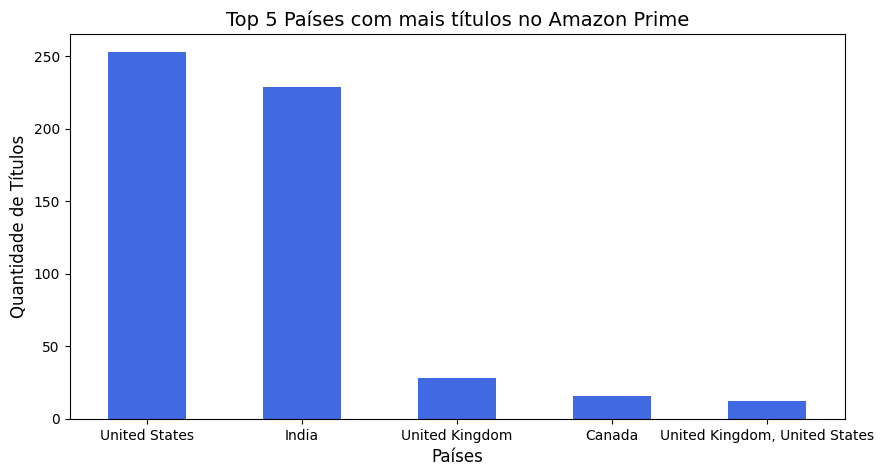

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

caminho_limpo = r"C:\ESTUDOS_DE_DADOS\01_Data\archive\amazon_prime_titles_LIMPO.csv"
df = pd.read_csv(caminho_limpo)

print(df.info())
print(df.describe())
print(f"{df.shape[0]} linhas x {df.shape[1]} colunas")

diretores_reais = df[df['director'] != 'Não informado']
top_diretores = diretores_reais['director'].value_counts().head(5)

países_reais = df[df['country'] != 'País Não Identificado']
top_países = países_reais['country'].value_counts().head(5)

def limpar_categorias(valor):
    if isinstance(valor, list):
        return valor
    elif isinstance(valor, str):
        if valor.startswith('['):
            try:
                return ast.literal_eval(valor)
            except:
                return [valor]
            else:
                return [cat.strip() for cat in valor.split(',')]
            return[]  

top_generos = df['listed_in'].value_counts().head(5)
df['listed_in'] = df['listed_in'].str.split(',')
df_exploded = df.explode('listed_in')
df['generos_reais'] = df['listed_in'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
generos_explodidos = df['generos_reais'].explode()
print(generos_explodidos.value_counts().head(10))

top_países.plot(kind='bar', color='royalblue', figsize=(10, 5))
plt.title('Top 5 Países com mais títulos no Amazon Prime', fontsize=14)
plt.xlabel('Países', fontsize=12)
plt.ylabel('Quantidade de Títulos', fontsize=12)
plt.xticks(rotation=0)
plt.show()

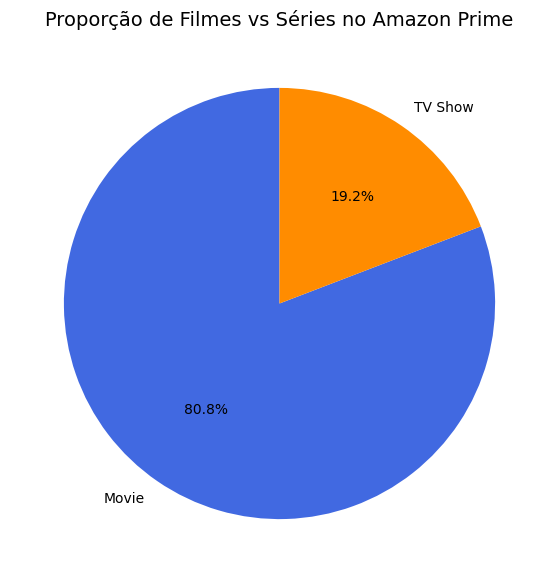

In [ ]:
tipo_conteudo = df['type'].value_counts()
tipo_conteudo.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['royalblue', 'darkorange'], figsize=(7, 7))

plt.title('Proporção de Filmes vs Séries no Amazon Prime', fontsize=14)
plt.ylabel('')
plt.show()